In [ ]:
from econml.dml import CausalForestDML
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier

In [26]:
DISCOUNT_EXPENSE_LOW = .15
DISCOUNT_EXPENSE_HI = .25
TECH_SUPPORT_EXPENSE_LOW = .07
TECH_SUPPORT_EXPENSE_HI = .12

### Load data and engineer variable

In [67]:
df = pd.read_csv('../data/software_usage_promotion.csv')

df['Combined Treatment'] = (df['Discount'] *
                            df['Tech Support']).astype('category')
confounders = [
    'Size', 'Employee Count', 'PC Count', 'IT Spend', 'Major Flag',
    'Global Flag', 'Commercial Flag', 'SMC Flag'
]

In [77]:
def update_revenue(row, disc_exp, tech_exp):
    revenue = row['Revenue']
    discount = row['Discount']
    tech = row['Tech Support']

    match(discount, tech):
        case (0, 0):
            return revenue
        case (1, 0):
            return revenue * (1 - disc_exp)
        case (0, 1):
            return revenue * (1 - tech_exp)
        case (1, 1):
            return revenue * (1 - tech_exp - disc_exp)

In [78]:
df['Revenue low expense'] = df.apply(update_revenue, disc_exp=DISCOUNT_EXPENSE_LOW, tech_exp=TECH_SUPPORT_EXPENSE_LOW, axis=1)
df['Revenue hi expense'] = df.apply(update_revenue, disc_exp=DISCOUNT_EXPENSE_HI, tech_exp=TECH_SUPPORT_EXPENSE_HI, axis=1)

### Model with CausalForest

In [80]:
def make_cf():
    return CausalForestDML(
        model_y=GradientBoostingRegressor(),
        model_t=DecisionTreeClassifier(max_depth=3),
        discrete_treatment=True,
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

In [ ]:
cf_discount = make_cf().fit(Y=df['Revenue'],
       T=df['Discount'],
       X=df[confounders])

cf_tech = make_cf().fit(Y=df['Revenue'], T=df['Tech Support'], X=df[confounders])

cf_combined = make_cf().fit(Y=df['Revenue'], T=df['Combined Treatment'], X=df[confounders])

In [ ]:
df['cate_discount'] = cf_discount.effect(df[confounders])
df['cate_tech_support'] = cf_tech.effect(df[confounders])
df['cate_both'] = cf_combined.effect(df[confounders])

### Determine Optimal Strategy

In [9]:
def row_optimal_strategy(row):
    discount = row['Discount']
    tech = row['Tech Support']

    match (discount, tech):
        case (0, 0):  # None
            lifts = {
                'none': 0,
                'discount': row['cate_discount'],
                'tech_support': row['cate_tech_support'],
                'both': row['cate_both']
            }
        case (1, 0): # Discount
            lifts = {
                'none': -row['cate_discount'],
                'discount': 0,
                'tech_support': row['cate_tech_support'] - row['cate_discount'],
                'both': row['cate_both'] - row['cate_discount']
            }
        case (0, 1): # Tech
            lifts = {
                'none': -row['cate_tech_support'],
                'discount': row['cate_discount'] - row['cate_tech_support'],
                'tech_support': 0,
                'both': row['cate_both'] - row['cate_tech_support']
            }
        case (1, 1): # Both
            lifts = {
                'none': -row['cate_both'],
                'discount': row['cate_discount'] - row['cate_both'],
                'tech_support': row['cate_tech_support'] - row['cate_both'],
                'both': 0
            }

        case _:  # fallback
            raise ValueError("Unexpected treatment combination")

    best_action = max(lifts, key=lifts.get)
    best_lift = lifts[best_action]

    return pd.Series({'recommended_action': best_action, 'incremental_lift': best_lift})


In [10]:
df[['recommended_action', 'incremental_lift']] = df.apply(row_optimal_strategy, axis=1)

In [11]:
rec_no_treatment = df[df.incremental_lift==0]

In [12]:
rec_no_treatment.shape

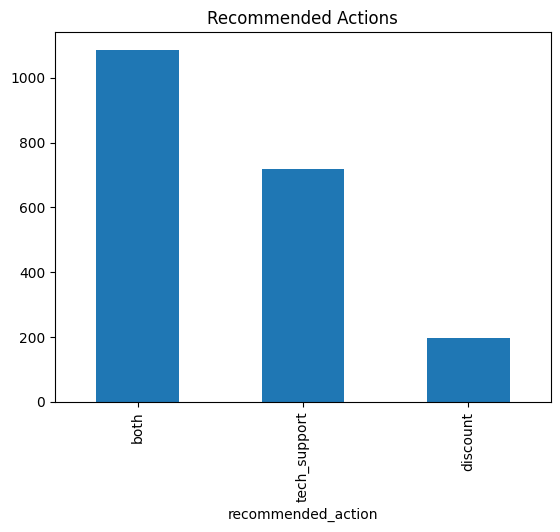

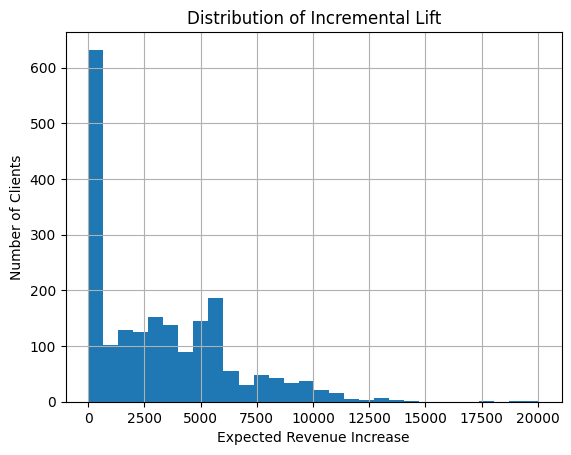

In [13]:
df['recommended_action'].value_counts().plot(kind='bar', title='Recommended Actions')
plt.show()

# Distribution of incremental lift
df['incremental_lift'].hist(bins=30)
plt.title('Distribution of Incremental Lift')
plt.xlabel('Expected Revenue Increase')
plt.ylabel('Number of Clients')
plt.show()

### Constraint-Based Recommendations

In [14]:
# Next step - need to think about actual policy
# i.e add treatments only if increase > x
# remove treaments only if decrease > y (y much greater than x)

In [15]:
curr_no_t = df.query("Discount==0 & `Tech Support`==0")

In [17]:
curr_no_t.shape

In [20]:
curr_no_t

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,Combined Treatment,cate_discount,cate_tech_support,cate_both,recommended_action,incremental_lift
6,1,0,0,0,40199,21,14,126342,0,0,9153.974376,0,7618.418393,8254.046666,9030.064221,both,9030.064221
7,0,0,1,1,30454,11,8,96784,0,0,5760.075096,0,4572.414739,6304.722504,7987.365334,both,7987.365334
12,0,0,1,1,19899,279,195,66555,0,0,11972.188180,0,4913.802231,6910.646123,7497.635385,both,7497.635385
22,0,0,1,0,14682,13,16,45908,0,0,2694.216001,0,2315.636326,5871.163710,5743.146915,tech_support,5871.163710
23,0,0,0,0,8321,82,50,26999,0,0,2531.466231,0,716.380591,5757.404705,4784.728909,tech_support,5757.404705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1987,1,0,0,1,14772,63,74,54855,0,0,8930.495022,0,2684.552280,6274.382318,5990.381519,tech_support,6274.382318
1992,0,0,1,1,4716,27,32,18150,0,0,4607.795027,0,744.676223,5191.807491,4232.479580,tech_support,5191.807491
1996,0,0,1,0,39683,12,13,111848,0,0,4753.072214,0,5037.999952,6960.693146,8595.033017,both,8595.033017
1997,0,1,0,0,4195,14,17,11924,0,0,2161.745939,0,973.376051,5237.215897,4984.517962,tech_support,5237.215897


In [19]:
curr_no_t.describe()

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,cate_discount,cate_tech_support,cate_both,incremental_lift
count,517.000000,517.000000,517.000000,517.00000,517.000000,517.000000,517.000000,517.000000,517.0,517.0,517.000000,517.000000,517.000000,517.000000,517.000000
mean,0.197292,0.191489,0.499033,0.72147,18055.644101,58.920696,54.740812,70943.249516,0.0,0.0,6585.891792,3637.574871,6395.917519,6801.601895,7125.132124
std,0.398340,0.393854,0.500483,0.44871,17169.883462,53.773386,51.556571,56892.441120,0.0,0.0,3363.163462,3066.898575,1109.945217,2188.153980,2066.381842
min,0.000000,0.000000,0.000000,0.00000,1161.000000,10.000000,6.000000,10101.000000,0.0,0.0,-616.572451,-403.651904,4894.039832,3791.696642,4894.039832
25%,0.000000,0.000000,0.000000,0.00000,6270.000000,22.000000,20.000000,26848.000000,0.0,0.0,4186.247555,1118.675593,5519.437176,4951.181372,5543.935907
50%,0.000000,0.000000,0.000000,1.00000,12749.000000,42.000000,40.000000,56512.000000,0.0,0.0,6123.187067,2762.563631,6096.840022,5955.878991,6254.771889
75%,0.000000,0.000000,1.000000,1.00000,24125.000000,74.000000,67.000000,96920.000000,0.0,0.0,8584.949530,5209.186239,7002.247275,8406.358091,8406.358091
max,1.000000,1.000000,1.000000,1.00000,169712.000000,535.000000,407.000000,426030.000000,0.0,0.0,21445.059370,20059.149994,11159.383799,17356.897652,20059.149994


In [ ]:
def make_final_recommendation(row):
    discount = row['Discount']
    tech_support = row['Tech Support']
    recommend = row['recommended_action']
    revenue = row['Revenue']
    lift = row['incremental_lift']

    match(discount, tech_support, recommend)
        case(0, 0, 'both') if revenue * lift > 0.15:
            return 'add both'
        case(0, 0, 'tech_support') if revenue * lift > 0.15:
            return 'add tech support'
        case(0, 0, 'discount') if revenue * lift > 0.15:
            return 'add_discount'
        case(0, 1, 'both') if revenue * lift > 0.15:
            return 'add discount'
        case(1, 0, 'both') if revenue * lift > 0.15:
            return 'add tech support'
        case(0, 1, 'none') if revenue * lift > 0.25:
            return 'remove tech support'
        case(1, 0, 'none') if revenue * lift > 0.25:
            return 'remove discount'
        case(1, 1, 'none') if revenue * lift > 0.25:
            return 'remove both'
        case(1, 1, 'tech_support') if revenue * lift > 0.25:
            return 'remove discount'
        case(1, 1, 'discount') if revenue * lift > 0.25:
            return 'remove tech support'
        case _:
            return 'no action'


SyntaxError: expected ':' (402346254.py, line 9)

In [ ]:
def model_wrapper(inp_df, rev_col)
    disc_model = make_cf().fit(Y=df[rev_col],
       T=df['Discount'],
       X=df[confounders])

    tech_model = make_cf().fit(Y=df[rev_col], T=df['Tech Support'], X=df[confounders])

    combined_model = make_cf().fit(Y=df[rev_col], T=df['Combined Treatment'], X=df[confounders])

    inp_df_ = inp_df.copy()

    inp_df_['cate_discount'] = disc_model.effect(df[confounders])
    inp_df_['cate_tech_support'] = tech_model.effect(df[confounders])
    inp_df_['cate_both'] = combined_model.effect(df[confounders])

    inp_df_[['recommended_action', 'incremental_lift']] = inp_df_.apply(row_optimal_strategy, axis=1)

    inp_df_['final_recommendation'] =